<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Leverage_ETFs/Log_Mean_Reversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Trading Strategy Backtesting with Logarithmic Trend Mean Reversion

This notebook develops and backtests a systematic trading strategy for TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) using a logarithmic trend mean reversion approach. The backtest period runs from TQQQ's inception date (February 11, 2010) to the present, utilizing adjusted prices from `yfinance`.

## Project Goals:
1.  **Develop a Mean Reversion Strategy:** Implement a strategy that profits from TQQQ's tendency to revert to its long-term logarithmic trend.
2.  **Compare Performance:** Evaluate the strategy against a TQQQ Buy and Hold benchmark using key metrics like CAGR, Max Drawdown, and visual equity curves.

## Strategy: Mean Reversion Strategy based on Logarithmic Trend
*   **Core Concept:** This strategy aims to profit from the tendency of TQQQ's price to revert to its long-term logarithmic trend. It identifies overbought and oversold conditions based on residuals from a linear regression of TQQQ's log price over time.
*   **Mechanics:** Uses Gaussian Mixture Models (GMM) to cluster the residuals into different regimes (e.g., most oversold, moderately oversold, moderately overbought, most overbought). Allocations to TQQQ are then dynamically adjusted based on these residual regimes, with higher allocations when TQQQ is oversold and lower/zero allocations when overbought.

## Benchmark: TQQQ Buy and Hold
*   **Core Concept:** A pure, passive buy-and-hold baseline to evaluate strategy outperformance (Alpha) and risk-adjusted return profiles.
*   **Mechanics:** Fully vectorized execution. 100% of capital is deployed into TQQQ on day one, compounding daily based on TQQQ's fractional percent changes.
*   **Historical Performance:** Historically (2010–2026), this benchmark compounds at a ~40% to 44% CAGR, but suffers an extreme maximum drawdown of ~81.6% during the 2022 market regime shift.

In [56]:
# Import necessary libraries

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available

In [57]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: tqqq_data
Deleted DataFrame: regression_df
Deleted DataFrame: X
Deleted DataFrame: strategy_df
All DataFrames cleared from memory.


In [58]:
# Download TQQQ data
tickers = ["TQQQ"]
tqqq_data = yf.download(tickers, start="2010-02-11", end="2026-01-01")['Close'].dropna()

# Convert to DataFrame if it's a Series (ensure tqqq_data is a DataFrame for subsequent operations)
if isinstance(tqqq_data, pd.Series):
    tqqq_data = tqqq_data.to_frame(name='TQQQ')

# Calculate TQQQ returns and create benchmark equity
tqqq_data['TQQQ_Return'] = tqqq_data['TQQQ'].pct_change()

# Create a copy for regression analysis and to serve as the consistent base for all strategies
regression_df = tqqq_data.copy()

# Calculate Standard_Benchmark_Equity once here to be used across all strategies
initial_portfolio_value_benchmark = 100000.0
# Use fillna(1) for the first return to correctly initialize cumprod for the benchmark
regression_df['Standard_Benchmark_Equity'] = (1 + regression_df['TQQQ_Return']).fillna(1).cumprod() * initial_portfolio_value_benchmark

print("TQQQ data and Benchmark Equity prepared.")

/tmp/ipykernel_7590/2983643939.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tqqq_data = yf.download(tickers, start="2010-02-11", end="2026-01-01")['Close'].dropna()
[*********************100%***********************]  1 of 1 completed

TQQQ data and Benchmark Equity prepared.


In [59]:
# Calculate TQQQ log price, trend line, and residuals
# These calculations are moved here to precede the plotting in cell 3e99eace

regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])
regression_df['Days_Since_Start'] = np.arange(len(regression_df))
X = regression_df[['Days_Since_Start']]
y = regression_df['TQQQ_Log_Price']
model = LinearRegression()
model.fit(X, y)
regression_df['TQQQ_Trend_Line'] = model.predict(X)
regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

print("TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df.")
display(regression_df[['TQQQ', 'TQQQ_Log_Price', 'TQQQ_Trend_Line', 'TQQQ_Residuals']].head())

TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df.


Ticker,TQQQ,TQQQ_Log_Price,TQQQ_Trend_Line,TQQQ_Residuals
Date,,,,
2010-02-11,0.206055,-1.579611,-1.290343,-0.289268
2010-02-12,0.206898,-1.575527,-1.288985,-0.286542
2010-02-16,0.214913,-1.537522,-1.287627,-0.249896
2010-02-17,0.218560,-1.520695,-1.286269,-0.234426
2010-02-18,0.222704,-1.501914,-1.284911,-0.217003


## Strategy 3: Mean Reversion Strategy based on Logarithmic Trend

Now, let's visualize the log price, the linear regression trend line, and the residuals. This will help us understand the deviations from the trend.

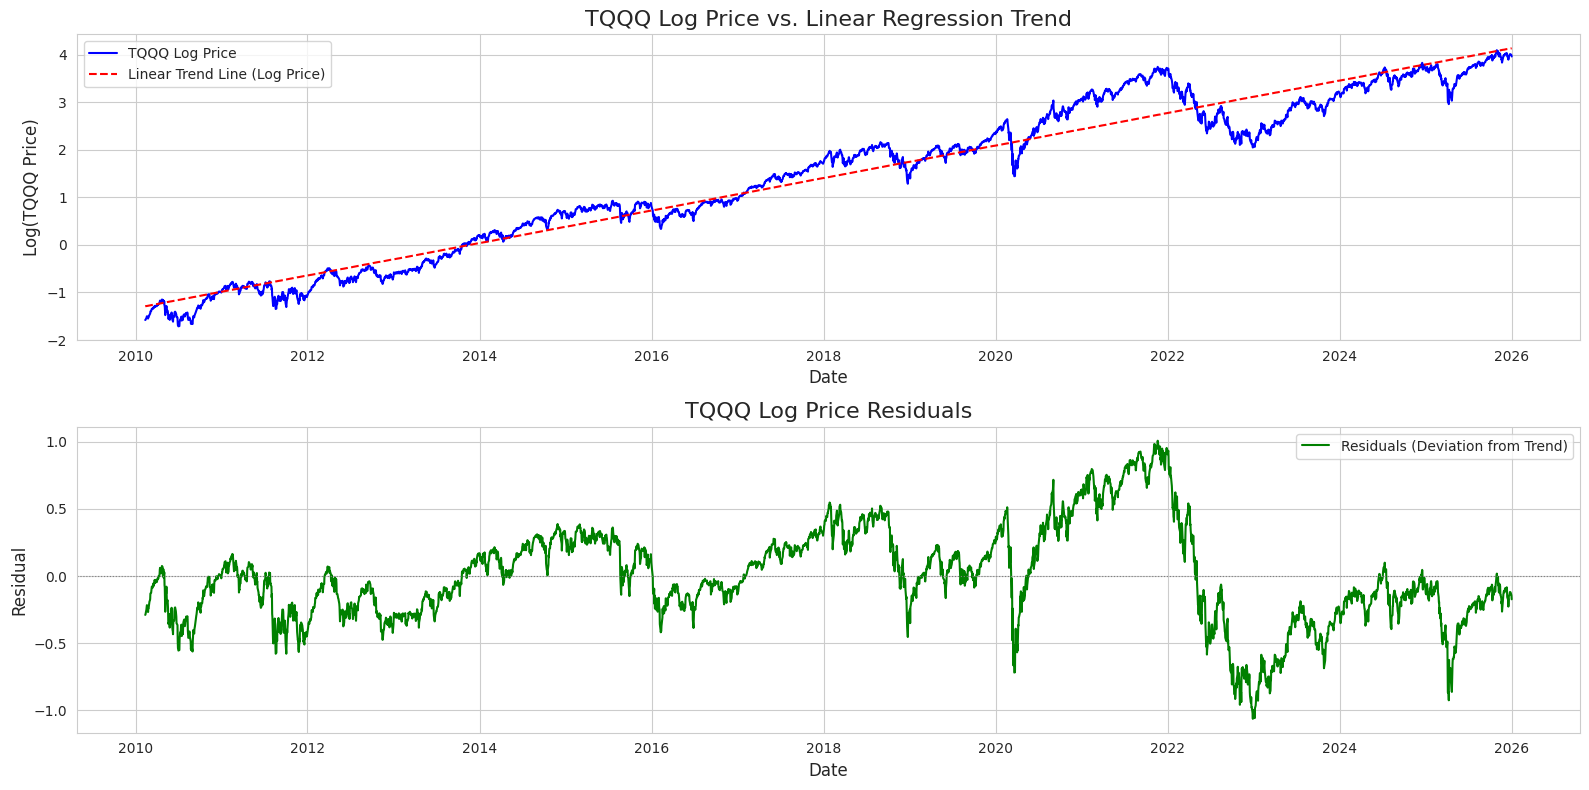

In [60]:
# Plot TQQQ log price, trend, and residuals
plt.figure(figsize=(16, 8))

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(regression_df.index, regression_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
plt.plot(regression_df.index, regression_df['TQQQ_Trend_Line'], label='Linear Trend Line (Log Price)', color='red', linestyle='--')
plt.title('TQQQ Log Price vs. Linear Regression Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log(TQQQ Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(regression_df.index, regression_df['TQQQ_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.title('TQQQ Log Price Residuals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()

The residuals represent how far TQQQ's log price is from its calculated long-term linear trend. A mean reversion strategy would typically involve:

1.  **Going Long (Buying TQQQ):** When the residuals fall significantly below zero, indicating TQQQ is oversold relative to its trend.
2.  **Going Short (Selling TQQQ):** When the residuals rise significantly above zero, indicating TQQQ is overbought relative to its trend.

You would need to define thresholds (e.g., standard deviations of residuals) to trigger these buy/sell signals.

## Mean Reversion Strategy Implementation

### Backtesting the Residual Mean Reversion Strategy

In [61]:
# --- Start of consolidated logic to prepare regression_df and create strategy_df ---

# (From b0ef9d33) Calculate TQQQ log price, trend line, and residuals
# Check if these columns already exist to prevent re-calculation if cells are run out of order
# Note: These calculations are now handled in cell 1da11918, so this block can be removed or kept as a safeguard
# if 'TQQQ_Log_Price' not in regression_df.columns:
#     regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])
#     regression_df['Days_Since_Start'] = np.arange(len(regression_df))
#     X = regression_df[['Days_Since_Start']]
#     y = regression_df['TQQQ_Log_Price']
#     model = LinearRegression()
#     model.fit(X, y)
#     regression_df['TQQQ_Trend_Line'] = model.predict(X)
#     regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

# (From f00c774e) Discover residual regimes using GMM and define allocations
# Check if these columns already exist to prevent re-calculation
if 'Target_Allocation' not in regression_df.columns:
    X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
    gmm_residuals = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
    raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)
    idx_residuals = np.argsort(gmm_residuals.means_.flatten())
    state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
    regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]
    allocation_map = {
        0: 1.0,  # Most oversold: 100% TQQQ
        1: 0.75, # Moderately oversold: 75% TQQQ
        2: 0.25, # Moderately overbought: 25% TQQQ
        3: 0.0   # Most overbought: 0% TQQQ (cash)
    }
    regression_df['Target_Allocation'] = regression_df['Residual_Regime'].map(allocation_map)

# (From 50d6af2c) Backtest Residual Mean Reversion Strategy and create strategy_df
# Only create strategy_df if it doesn't already exist in the current session
if 'strategy_df' not in locals() or strategy_df is None:
    strategy_df = regression_df[['TQQQ', 'TQQQ_Return', 'Target_Allocation']].copy()
    strategy_df['TQQQ_Daily_Return'] = strategy_df['TQQQ_Return']
    strategy_df = strategy_df.dropna()
    strategy_df['Allocated_Weight'] = strategy_df['Target_Allocation'].shift(1)
    strategy_df = strategy_df.dropna()
    strategy_df['Strategy_Daily_Return'] = strategy_df['Allocated_Weight'] * strategy_df['TQQQ_Daily_Return']
    initial_portfolio_value = 100000.0
    strategy_df['Strategy_Equity'] = (1 + strategy_df['Strategy_Daily_Return']).cumprod() * initial_portfolio_value
    strategy_df['Benchmark_Equity'] = regression_df['Standard_Benchmark_Equity'].reindex(strategy_df.index)

# --- End of consolidated logic ---

# Performance Metrics Calculation
# (Using the same calculate_metrics function from earlier, if defined. If not, redefining it here for robustness.)
def calculate_metrics(return_series, equity_series, initial_value):
    if len(equity_series) == 0 or initial_value == 0:
        return 0.0, 0.0, 0.0, 0.0

    total_return = (equity_series.iloc[-1] / initial_value - 1)
    # Ensure we have enough data points for annualization
    if len(equity_series) < 252:
        years = len(equity_series) / 252.0 if len(equity_series) > 0 else 1.0
    else:
        years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25

    cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100 if years > 0 else 0.0
    ann_vol = return_series.std() * np.sqrt(252) * 100
    sharpe = cagr / ann_vol if ann_vol != 0 else 0.0

    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    max_dd = drawdowns.min() * 100
    return cagr, ann_vol, sharpe, max_dd

strat_cagr, strat_vol, strat_sharpe, strat_mdd = calculate_metrics(
    strategy_df['Strategy_Daily_Return'], strategy_df['Strategy_Equity'], initial_portfolio_value)
bench_cagr, bench_vol, bench_sharpe, bench_mdd = calculate_metrics(
    strategy_df['TQQQ_Daily_Return'], strategy_df['Benchmark_Equity'], initial_portfolio_value)

final_strat_equity = strategy_df['Strategy_Equity'].iloc[-1]
final_bench_equity = strategy_df['Benchmark_Equity'].iloc[-1]

val_strat_str = f"${final_strat_equity:,.2f}"
val_bench_str = f"${final_bench_equity:,.2f}"
cagr_strat_str = f"{strat_cagr:.2f}%"
cagr_bench_str = f"{bench_cagr:.2f}%"
mdd_strat_str = f"{strat_mdd:.2f}%"
mdd_bench_str = f"{bench_mdd:.2f}%"

print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)


Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $27,314,155.37           $25,543,133.68      
CAGR                     42.40%                   41.80%              
Annualized Vol           41.75%                   61.11%              
Sharpe Ratio             1.02                     0.68                
Max Drawdown             -53.01%                  -81.66%             
----------------------------------------------------------------------


### Residual Mean Reversion Strategy Equity Curve

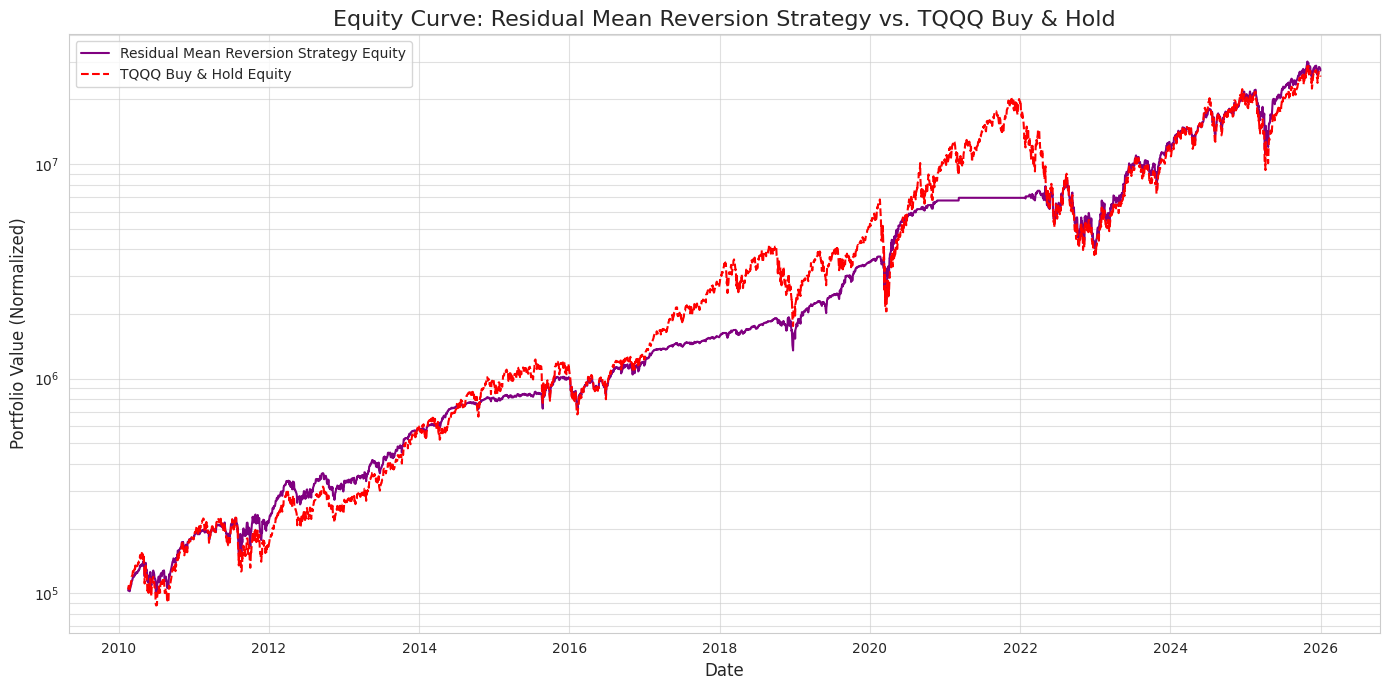

In [62]:
# Plot equity curve for Residual Mean Reversion Strategy
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df.index, strategy_df['Strategy_Equity'], label='Residual Mean Reversion Strategy Equity', color='purple')
plt.plot(strategy_df.index, strategy_df['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()